In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
import tqdm


# ============================================================
# Parameters
# ============================================================


@dataclass
class Params:
    theta_L: float = 0.1
    theta_H: float = 0.9

    rho_minus: float = 0.20
    rho_plus: float = 0.80

    # User payoff parameters
    r: float = 1.0
    e: float = 0.50
    c: float = 0.20

    # Discount factor
    delta: float = 0.05

    eps: float = 1e-9


P = Params()

# Optional: uncomment one of these to force a knife-edge row in Table 1
# P.delta = 0.5
# P.delta = (1.0 - P.rho_minus) / (2.0 - P.rho_minus)   # activates Table 1 row 5
# P.delta = (1.0 - P.rho_plus) / (2.0 - P.rho_plus)     # activates Table 1 row 6

rho_star = 1.0 - (P.e - P.c) / P.r

assert 0 < P.theta_L < P.theta_H < 1
assert 0 < P.rho_minus < rho_star < P.rho_plus < 1
assert 0 < P.delta < 1


# ============================================================
# Basic functions
# ============================================================


def theta_bar(mu, P=P):
    return mu * P.theta_H + (1.0 - mu) * P.theta_L


def trust_threshold(P=P):
    return (rho_star - P.rho_minus) / (P.rho_plus - rho_star)


def trust_score(h, mu, P=P):
    A = theta_bar(mu, P)
    return (A / (1.0 - A)) * (1.0 / (1.0 - h))


def clip01(x, P=P):
    return min(max(x, P.eps), 1.0 - P.eps)


def in_tau_C(h, mu, P=P):
    if np.isnan(h) or np.isnan(mu):
        return False
    h = clip01(h, P)
    mu = clip01(mu, P)
    return trust_score(h, mu, P) >= trust_threshold(P) - P.eps


def in_tau_D(h, mu, P=P):
    if np.isnan(h) or np.isnan(mu):
        return False
    return not in_tau_C(h, mu, P)


def same_region(h1, mu1, h2, mu2, P=P):
    if any(np.isnan(x) for x in [h1, mu1, h2, mu2]):
        return False
    return (in_tau_C(h1, mu1, P) and in_tau_C(h2, mu2, P)) or (
        in_tau_D(h1, mu1, P) and in_tau_D(h2, mu2, P)
    )


def user_ic_total_delegation(u, P=P):
    return (u["rho_tilde_plus"] >= rho_star - P.eps) and (
        u["rho_tilde_minus"] >= rho_star - P.eps
    )


def user_ic_total_rejection(u, P=P):
    return (u["rho_tilde_plus"] <= rho_star + P.eps) and (
        u["rho_tilde_minus"] <= rho_star + P.eps
    )


def user_ic_inverted_delegation(u, P=P):
    return (u["rho_tilde_plus"] <= rho_star + P.eps) and (
        u["rho_tilde_minus"] >= rho_star - P.eps
    )


# ============================================================
# Delta filter for Table 1
# ============================================================


def delta_ratio(P=P):
    return P.delta / (1.0 - P.delta)


def delta_condition_table1(row, P=P):
    R = delta_ratio(P)

    if row == 1:
        return True
    if row == 2:
        return P.delta > 0.5 + P.eps
    if row == 3:
        return abs(P.delta - 0.5) <= P.eps
    if row == 4:
        return R > (1.0 - P.rho_minus) + P.eps
    if row == 5:
        return abs(R - (1.0 - P.rho_minus)) <= P.eps
    if row == 6:
        return abs(R - (1.0 - P.rho_plus)) <= P.eps

    raise ValueError("Unknown Table 1 row")


def delta_condition_table4(row, P=P):
    R = delta_ratio(P)

    if row == 1:
        return abs(R - P.rho_minus) <= P.eps
    if row == 2:
        return abs(R - P.rho_plus) <= P.eps
    if row == 3:
        return abs(P.delta - 0.5) <= P.eps

    raise ValueError("Unknown Table 4 row")


# ============================================================
# Reputation dynamics from Section C
# ============================================================


def reputation_updates(h, mu, sigma_plus, sigma_minus, P=P):
    A = theta_bar(mu, P)

    P_plus = h * A + (1.0 - h) * (A * sigma_plus + (1.0 - A) * sigma_minus)
    P_minus = 1.0 - P_plus

    out = {
        "P_plus": P_plus,
        "P_minus": P_minus,
    }

    # ---------- signal rho^+ ----------
    if P_plus <= P.eps:
        out.update(
            {
                "h_tilde_plus": np.nan,
                "mu_tilde_plus": np.nan,
                "theta_tilde_plus": np.nan,
                "rho_tilde_plus": np.nan,
                "h_success_plus": np.nan,
                "h_fail_plus": np.nan,
                "mu_success_plus": np.nan,
                "mu_fail_plus": np.nan,
            }
        )
    else:
        h_tilde_plus = h * A / P_plus

        mu_tilde_plus = (
            mu
            * (
                h * P.theta_H
                + (1.0 - h) * (P.theta_H * sigma_plus + (1.0 - P.theta_H) * sigma_minus)
            )
            / P_plus
        )

        theta_tilde_plus = A * (h + (1.0 - h) * sigma_plus) / P_plus

        rho_tilde_plus = (
            theta_tilde_plus * P.rho_plus + (1.0 - theta_tilde_plus) * P.rho_minus
        )

        h_success_plus = (P.rho_plus / rho_tilde_plus) * h_tilde_plus
        h_fail_plus = ((1.0 - P.rho_plus) / (1.0 - rho_tilde_plus)) * h_tilde_plus

        mu_success_plus = (
            mu
            * (
                h * P.theta_H * P.rho_plus
                + (1.0 - h)
                * (
                    P.rho_plus * P.theta_H * sigma_plus
                    + P.rho_minus * (1.0 - P.theta_H) * sigma_minus
                )
            )
            / (rho_tilde_plus * P_plus)
        )

        mu_fail_plus = (
            mu
            * (
                h * P.theta_H * (1.0 - P.rho_plus)
                + (1.0 - h)
                * (
                    (1.0 - P.rho_plus) * P.theta_H * sigma_plus
                    + (1.0 - P.rho_minus) * (1.0 - P.theta_H) * sigma_minus
                )
            )
            / ((1.0 - rho_tilde_plus) * P_plus)
        )

        out.update(
            {
                "h_tilde_plus": h_tilde_plus,
                "mu_tilde_plus": mu_tilde_plus,
                "theta_tilde_plus": theta_tilde_plus,
                "rho_tilde_plus": rho_tilde_plus,
                "h_success_plus": h_success_plus,
                "h_fail_plus": h_fail_plus,
                "mu_success_plus": mu_success_plus,
                "mu_fail_plus": mu_fail_plus,
            }
        )

    # ---------- signal rho^- ----------
    if P_minus <= P.eps:
        out.update(
            {
                "h_tilde_minus": np.nan,
                "mu_tilde_minus": np.nan,
                "theta_tilde_minus": np.nan,
                "rho_tilde_minus": np.nan,
                "h_success_minus": np.nan,
                "h_fail_minus": np.nan,
                "mu_success_minus": np.nan,
                "mu_fail_minus": np.nan,
            }
        )
    else:
        h_tilde_minus = h * (1.0 - A) / P_minus

        mu_tilde_minus = (
            mu
            * (
                h * (1.0 - P.theta_H)
                + (1.0 - h)
                * (
                    P.theta_H * (1.0 - sigma_plus)
                    + (1.0 - P.theta_H) * (1.0 - sigma_minus)
                )
            )
            / P_minus
        )

        theta_tilde_minus = A * (1.0 - h) * (1.0 - sigma_plus) / P_minus

        rho_tilde_minus = (
            theta_tilde_minus * P.rho_plus + (1.0 - theta_tilde_minus) * P.rho_minus
        )

        h_success_minus = (P.rho_minus / rho_tilde_minus) * h_tilde_minus
        h_fail_minus = ((1.0 - P.rho_minus) / (1.0 - rho_tilde_minus)) * h_tilde_minus

        mu_success_minus = (
            mu
            * (
                h * (1.0 - P.theta_H) * P.rho_minus
                + (1.0 - h)
                * (
                    P.rho_plus * P.theta_H * (1.0 - sigma_plus)
                    + P.rho_minus * (1.0 - P.theta_H) * (1.0 - sigma_minus)
                )
            )
            / (rho_tilde_minus * P_minus)
        )

        mu_fail_minus = (
            mu
            * (
                h * (1.0 - P.theta_H) * (1.0 - P.rho_minus)
                + (1.0 - h)
                * (
                    (1.0 - P.rho_plus) * P.theta_H * (1.0 - sigma_plus)
                    + (1.0 - P.rho_minus) * (1.0 - P.theta_H) * (1.0 - sigma_minus)
                )
            )
            / ((1.0 - rho_tilde_minus) * P_minus)
        )

        out.update(
            {
                "h_tilde_minus": h_tilde_minus,
                "mu_tilde_minus": mu_tilde_minus,
                "theta_tilde_minus": theta_tilde_minus,
                "rho_tilde_minus": rho_tilde_minus,
                "h_success_minus": h_success_minus,
                "h_fail_minus": h_fail_minus,
                "mu_success_minus": mu_success_minus,
                "mu_fail_minus": mu_fail_minus,
            }
        )

    return out

In [14]:
# ============================================================
# Table 1 conditions: Standard Delegation
# ============================================================


def cond_T1R1(h, mu, u, P=P):
    return in_tau_C(h, mu, P) and in_tau_C(u["h_fail_plus"], u["mu_fail_plus"], P)


def cond_T1R2(h, mu, u, P=P):
    return in_tau_C(h, mu, P) and in_tau_D(u["h_success_plus"], u["mu_success_plus"], P)


def cond_T1R3(h, mu, u, P=P):
    return in_tau_C(u["h_tilde_minus"], u["mu_tilde_minus"], P) and in_tau_D(
        u["h_success_plus"], u["mu_success_plus"], P
    )


def cond_T1R4(h, mu, u, P=P):
    return (
        in_tau_C(h, mu, P)
        and in_tau_C(u["h_success_plus"], u["mu_success_plus"], P)
        and in_tau_D(u["h_fail_plus"], u["mu_fail_plus"], P)
    )


def cond_T1R5(h, mu, u, P=P):
    return (
        in_tau_C(u["h_tilde_minus"], u["mu_tilde_minus"], P)
        and in_tau_C(u["h_success_plus"], u["mu_success_plus"], P)
        and in_tau_D(u["h_fail_plus"], u["mu_fail_plus"], P)
    )


def cond_T1R6(h, mu, u, P=P):
    # same as displayed in the previous screenshot
    return (
        in_tau_C(u["h_tilde_minus"], u["mu_tilde_minus"], P)
        and in_tau_C(u["h_success_plus"], u["mu_success_plus"], P)
        and in_tau_D(u["h_fail_plus"], u["mu_fail_plus"], P)
    )


# ============================================================
# Table 2 conditions: Total Delegation
# ============================================================


def cond_T2R1(h, mu, u, P=P):
    # exact visible conditions + user IC for total delegation
    return (
        user_ic_total_delegation(u, P)
        and same_region(
            u["h_success_plus"],
            u["mu_success_plus"],
            u["h_fail_plus"],
            u["mu_fail_plus"],
            P,
        )
        and same_region(
            u["h_success_minus"],
            u["mu_success_minus"],
            u["h_fail_minus"],
            u["mu_fail_minus"],
            P,
        )
    )


# ============================================================
# Table 3 conditions: Total Rejection
# ============================================================


def cond_T3R1(h, mu, u, P=P):
    return (
        user_ic_total_rejection(u, P)
        and in_tau_D(u["h_tilde_minus"], u["mu_tilde_minus"], P)
        and in_tau_D(u["h_tilde_plus"], u["mu_tilde_plus"], P)
    )


def cond_T3R2(h, mu, u, P=P):
    return (
        user_ic_total_rejection(u, P)
        and in_tau_C(u["h_tilde_minus"], u["mu_tilde_minus"], P)
        and in_tau_C(u["h_tilde_plus"], u["mu_tilde_plus"], P)
    )


### EDIT
# ============================================================
# Table 4 conditions: Inverted Delegation
# ============================================================


def cond_T4R1(h, mu, u, P=P):
    return (
        user_ic_inverted_delegation(u, P)
        and in_tau_C(u["h_tilde_plus"], u["mu_tilde_plus"], P)
        and in_tau_D(u["h_success_minus"], u["mu_success_minus"], P)
        and in_tau_C(u["h_fail_minus"], u["mu_fail_minus"], P)
    )


def cond_T4R2(h, mu, u, P=P):
    return (
        user_ic_inverted_delegation(u, P)
        and in_tau_C(u["h_tilde_plus"], u["mu_tilde_plus"], P)
        and in_tau_D(u["h_success_minus"], u["mu_success_minus"], P)
        and in_tau_C(u["h_fail_minus"], u["mu_fail_minus"], P)
    )


def cond_T4R3(h, mu, u, P=P):
    return (
        user_ic_inverted_delegation(u, P)
        and in_tau_C(u["h_tilde_plus"], u["mu_tilde_plus"], P)
        and in_tau_D(u["h_success_minus"], u["mu_success_minus"], P)
        and in_tau_D(u["h_fail_minus"], u["mu_fail_minus"], P)
    )

In [12]:
# ============================================================
# Strategy samplers
# ============================================================


def sampler_table1_row(row, n=50):
    # Table 1
    if row in [1, 2, 4]:
        return [(1.0, 1.0, "sigma(+)=1, sigma(-)=1")]

    if row == 3:
        # row 3 appears to be sigma(.) in [0,1], i.e. same value for both
        grid = np.linspace(0.0, 1.0, n)
        return [(s, s, f"sigma(+)=sigma(-)={s:.3f}") for s in grid]

    if row == 5:
        # sigma(+)=1, sigma(-) in (0,1]
        grid_minus = np.linspace(0.0, 1.0, n + 1)[1:]
        return [(1.0, sm, f"sigma(+)=1, sigma(-)={sm:.3f}") for sm in grid_minus]

    if row == 6:
        # sigma(+) in [0,1), sigma(-) in (0,1]
        grid_plus = np.linspace(0.0, 1.0, n + 1)[:-1]
        grid_minus = np.linspace(0.0, 1.0, n + 1)[1:]
        return [
            (sp, sm, f"sigma(+)={sp:.3f}, sigma(-)={sm:.3f}")
            for sp in grid_plus
            for sm in grid_minus
        ]

    raise ValueError("Unknown Table 1 row")


def sampler_table2_row(row, n=10):
    # Table 2 row 1*: sigma(+) in [0,1], sigma(-) in [0,1]
    grid = np.linspace(0.0, 1.0, n)
    return [
        (sp, sm, f"sigma(+)={sp:.3f}, sigma(-)={sm:.3f}") for sp in grid for sm in grid
    ]


def sampler_table3_row(row, n=10):
    # Table 3 rows: sigma(+) in [0,1], sigma(-) in (0,1]
    grid_plus = np.linspace(0.0, 1.0, n)
    grid_minus = np.linspace(0.0, 1.0, n + 1)[1:]
    return [
        (sp, sm, f"sigma(+)={sp:.3f}, sigma(-)={sm:.3f}")
        for sp in grid_plus
        for sm in grid_minus
    ]


### EDIT
def sampler_table4_row(row, n=10):
    # Table 4 rows:
    grid_plus = np.linspace(0.0, 1.0, n + 1)[:-1]
    grid_minus = np.linspace(0.0, 1.0, n + 1)[1:]
    strict_mix = np.linspace(0.0, 1.0, n + 2)[1:-1]

    if row == 1:
        return [(0, sm, f"sigma(+)=0, sigma(-)={sm:.3f}") for sm in strict_mix]

    if row == 2:
        return [(sp, 1, f"sigma(+)={sp:.3f}, sigma(-)=1") for sp in strict_mix]

    if row == 3:
        return [
            (sp, sm, f"sigma(+)={sp:.3f}, sigma(-)={sm:.3f}")
            for sp in grid_plus
            for sm in grid_minus
        ]


# ============================================================
# Row specs
# ============================================================

ROW_SPECS = [
    # Table 1
    {
        "key": "T1R1",
        "table": "Table 1: Standard Delegation",
        "row": 1,
        "condition": cond_T1R1,
        "sampler": sampler_table1_row,
        "active": lambda P=P: delta_condition_table1(1, P),
        "color": "tab:blue",
    },
    {
        "key": "T1R2",
        "table": "Table 1: Standard Delegation",
        "row": 2,
        "condition": cond_T1R2,
        "sampler": sampler_table1_row,
        "active": lambda P=P: delta_condition_table1(2, P),
        "color": "tab:orange",
    },
    {
        "key": "T1R3",
        "table": "Table 1: Standard Delegation",
        "row": 3,
        "condition": cond_T1R3,
        "sampler": sampler_table1_row,
        "active": lambda P=P: delta_condition_table1(3, P),
        "color": "tab:green",
    },
    {
        "key": "T1R4",
        "table": "Table 1: Standard Delegation",
        "row": 4,
        "condition": cond_T1R4,
        "sampler": sampler_table1_row,
        "active": lambda P=P: delta_condition_table1(4, P),
        "color": "tab:red",
    },
    {
        "key": "T1R5",
        "table": "Table 1: Standard Delegation",
        "row": 5,
        "condition": cond_T1R5,
        "sampler": sampler_table1_row,
        "active": lambda P=P: delta_condition_table1(5, P),
        "color": "tab:purple",
    },
    {
        "key": "T1R6",
        "table": "Table 1: Standard Delegation",
        "row": 6,
        "condition": cond_T1R6,
        "sampler": sampler_table1_row,
        "active": lambda P=P: delta_condition_table1(6, P),
        "color": "tab:brown",
    },
    # Table 2
    {
        "key": "T2R1",
        "table": "Table 2: Total Delegation",
        "row": 1,
        "condition": cond_T2R1,
        "sampler": sampler_table2_row,
        "active": lambda P=P: True,
        "color": "tab:pink",
    },
    # Table 3
    {
        "key": "T3R1",
        "table": "Table 3: Total Rejection",
        "row": 1,
        "condition": cond_T3R1,
        "sampler": sampler_table3_row,
        "active": lambda P=P: True,
        "color": "tab:gray",
    },
    {
        "key": "T3R2",
        "table": "Table 3: Total Rejection",
        "row": 2,
        "condition": cond_T3R2,
        "sampler": sampler_table3_row,
        "active": lambda P=P: True,
        "color": "olive",
    },
    # Table 4
    {
        "key": "T4R1",
        "table": "Table 4: Inverted Delegation",
        "row": 1,
        "condition": cond_T4R1,
        "sampler": sampler_table4_row,
        "active": lambda P=P: delta_condition_table4(1, P),
        "color": "tab:cyan",
    },
    {
        "key": "T4R2",
        "table": "Table 4: Inverted Delegation",
        "row": 2,
        "condition": cond_T4R2,
        "sampler": sampler_table4_row,
        "active": lambda P=P: delta_condition_table4(2, P),
        "color": "yellow",
    },
    {
        "key": "T4R3",
        "table": "Table 4: Inverted Delegation",
        "row": 3,
        "condition": cond_T4R3,
        "sampler": sampler_table4_row,
        "active": lambda P=P: delta_condition_table4(3, P),
        "color": "black",
    },
]

In [48]:
# ============================================================
# Scan settings
# ============================================================


P = Params(delta=0.8, eps=1e-6)

N_GRID = 99
N_MIXED_SAMPLES = 10
MAX_FAILURES_TO_SAVE = 4000000

h_values = np.linspace(0.01, 0.99, N_GRID)
mu_values = np.linspace(0.01, 0.99, N_GRID)

ACTIVE_SPECS = [spec for spec in ROW_SPECS if spec["active"](P)]

Parameters
Params(theta_L=0.1, theta_H=0.9, rho_minus=0.2, rho_plus=0.8, r=1.0, e=0.5, c=0.2, delta=0.8, eps=1e-06)
rho_star = 0.700000
delta/(1-delta) = 4.000000
tau threshold = 5.000000
Active rows:
  T1R1: Table 1: Standard Delegation, row 1
  T1R2: Table 1: Standard Delegation, row 2
  T1R4: Table 1: Standard Delegation, row 4
  T2R1: Table 2: Total Delegation, row 1
  T3R1: Table 3: Total Rejection, row 1
  T3R2: Table 3: Total Rejection, row 2



Specs: 100%|██████████| 6/6 [00:47<00:00,  7.88s/it]


    key                         table  row       color  num_satisfying_points
0  T1R1  Table 1: Standard Delegation    1    tab:blue                   1811
1  T1R2  Table 1: Standard Delegation    2  tab:orange                      1
2  T1R4  Table 1: Standard Delegation    4     tab:red                   1299
3  T2R1     Table 2: Total Delegation    1    tab:pink                   5475
4  T3R1      Table 3: Total Rejection    1    tab:gray                 454778
5  T3R2      Table 3: Total Rejection    2       olive                   2117

Saved summary_all_tables_2026-05-08 22:30:18    .csv
Saved failed_constraints_all_tables_2026-05-08 22:30:18.csv with 2504222 rows


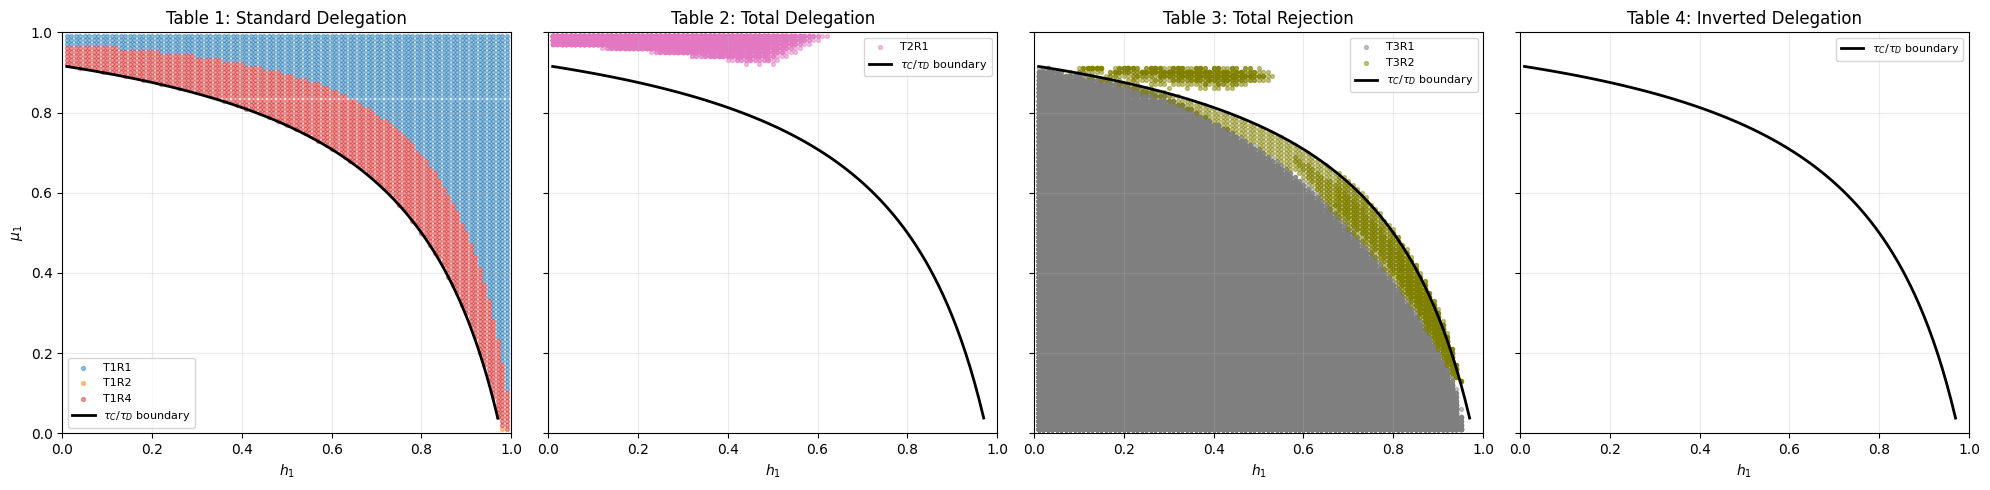

Saved equilibrium_regions_all_tables.png


In [ ]:
# ============================================================
# Run scan
# ============================================================
import itertools

success_points = {spec["key"]: [] for spec in ACTIVE_SPECS}
failures = []
summary = []

print("========================================")
print("Parameters")
print("========================================")
print(P)
print(f"rho_star = {rho_star:.6f}")
print(f"delta/(1-delta) = {delta_ratio(P):.6f}")
print(f"tau threshold = {trust_threshold(P):.6f}")
print("Active rows:")
for spec in ACTIVE_SPECS:
    print(f"  {spec['key']}: {spec['table']}, row {spec['row']}")
print("========================================\n")

for spec in tqdm.tqdm(ACTIVE_SPECS, desc="Specs"):
    key = spec["key"]
    cond = spec["condition"]
    strategy_samples = spec["sampler"](spec["row"], N_MIXED_SAMPLES)

    count_success = 0

    grid_search = list(itertools.product(h_values, mu_values))

    for h, mu in tqdm.tqdm(grid_search, desc=f"Scanning {key}", leave=False):
        for sigma_plus, sigma_minus, strategy_label in strategy_samples:
            u = reputation_updates(h, mu, sigma_plus, sigma_minus, P)

            ok = cond(h, mu, u, P)

            if ok:
                success_points[key].append((h, mu, sigma_plus, sigma_minus))
                count_success += 1
            else:
                if MAX_FAILURES_TO_SAVE is None or len(failures) < MAX_FAILURES_TO_SAVE:
                    failures.append(
                        {
                            "key": key,
                            "table": spec["table"],
                            "row": spec["row"],
                            "h1": h,
                            "mu1": mu,
                            "sigma_plus": sigma_plus,
                            "sigma_minus": sigma_minus,
                            "strategy": strategy_label,
                            "delta": P.delta,
                            "delta_ratio": delta_ratio(P),
                            "rho_star": rho_star,
                            "tau_threshold": trust_threshold(P),
                            "P_plus": u.get("P_plus", np.nan),
                            "P_minus": u.get("P_minus", np.nan),
                            "h_tilde_plus": u.get("h_tilde_plus", np.nan),
                            "mu_tilde_plus": u.get("mu_tilde_plus", np.nan),
                            "rho_tilde_plus": u.get("rho_tilde_plus", np.nan),
                            "h_tilde_minus": u.get("h_tilde_minus", np.nan),
                            "mu_tilde_minus": u.get("mu_tilde_minus", np.nan),
                            "rho_tilde_minus": u.get("rho_tilde_minus", np.nan),
                            "h_success_plus": u.get("h_success_plus", np.nan),
                            "mu_success_plus": u.get("mu_success_plus", np.nan),
                            "h_fail_plus": u.get("h_fail_plus", np.nan),
                            "mu_fail_plus": u.get("mu_fail_plus", np.nan),
                            "h_success_minus": u.get("h_success_minus", np.nan),
                            "mu_success_minus": u.get("mu_success_minus", np.nan),
                            "h_fail_minus": u.get("h_fail_minus", np.nan),
                            "mu_fail_minus": u.get("mu_fail_minus", np.nan),
                            "in_tauC_h_mu": in_tau_C(h, mu, P),
                            "in_tauC_tilde_plus": in_tau_C(
                                u.get("h_tilde_plus", np.nan),
                                u.get("mu_tilde_plus", np.nan),
                                P,
                            ),
                            "in_tauC_tilde_minus": in_tau_C(
                                u.get("h_tilde_minus", np.nan),
                                u.get("mu_tilde_minus", np.nan),
                                P,
                            ),
                            "in_tauC_success_plus": in_tau_C(
                                u.get("h_success_plus", np.nan),
                                u.get("mu_success_plus", np.nan),
                                P,
                            ),
                            "in_tauC_fail_plus": in_tau_C(
                                u.get("h_fail_plus", np.nan),
                                u.get("mu_fail_plus", np.nan),
                                P,
                            ),
                            "in_tauC_success_minus": in_tau_C(
                                u.get("h_success_minus", np.nan),
                                u.get("mu_success_minus", np.nan),
                                P,
                            ),
                            "in_tauC_fail_minus": in_tau_C(
                                u.get("h_fail_minus", np.nan),
                                u.get("mu_fail_minus", np.nan),
                                P,
                            ),
                            "user_ic_total_delegate": user_ic_total_delegation(u, P),
                            "user_ic_total_reject": user_ic_total_rejection(u, P),
                        }
                    )

    summary.append(
        {
            "key": key,
            "table": spec["table"],
            "row": spec["row"],
            "color": spec["color"],
            "num_satisfying_points": count_success,
        }
    )


summary_df = pd.DataFrame(summary)
failure_df = pd.DataFrame(failures)

timestamp = pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")

summary_df.to_csv(f"summary_all_tables_{timestamp}.csv", index=False)
# failure_df.to_csv(f"failed_constraints_all_tables_{timestamp}.csv", index=False)

print(summary_df)
print()
print(f"Saved summary_all_tables_{timestamp}    .csv")
# print(f"Saved failed_constraints_all_tables_{timestamp}.csv with {len(failure_df)} rows")


# ============================================================
# Plot
# ============================================================

table_names = [
    "Table 1: Standard Delegation",
    "Table 2: Total Delegation",
    "Table 3: Total Rejection",
    "Table 4: Inverted Delegation",
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharex=True, sharey=True)

for ax, table_name in zip(axes, table_names):
    for spec in ACTIVE_SPECS:
        if spec["table"] != table_name:
            continue

        pts = np.array(success_points[spec["key"]])
        if len(pts) == 0:
            continue

        ax.scatter(
            pts[:, 0],
            pts[:, 1],
            s=8,
            alpha=0.45,
            color=spec["color"],
            label=f"{spec['key']}",
        )

    # tau_C/tau_D boundary
    h_grid = np.linspace(0.01, 0.99, 99)
    T = trust_threshold(P)
    A_boundary = T * (1.0 - h_grid) / (1.0 + T * (1.0 - h_grid))
    mu_boundary = (A_boundary - P.theta_L) / (P.theta_H - P.theta_L)
    mask = (mu_boundary >= 0.0) & (mu_boundary <= 1.0)

    ax.plot(
        h_grid[mask],
        mu_boundary[mask],
        color="black",
        linewidth=2,
        label=r"$\tau_C/\tau_D$ boundary",
    )

    ax.set_title(table_name)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8, loc="best")

axes[0].set_ylabel(r"$\mu_1$")
for ax in axes:
    ax.set_xlabel(r"$h_1$")

plt.tight_layout()
plt.savefig(f"equilibrium_regions_all_tables_{timestamp}.png", dpi=300)
plt.show()

print("Saved equilibrium_regions_all_tables.png")